## Part 2: Spatial Networks and Road Events in Leeds

### Task A: Spatial Network Extraction and Planarity Testing

Unlike virtual social networks, urban traffic analysis must be grounded in a rigorous geographic coordinate system. The objective of this task is to extract and characterize the physical road infrastructure utilizing the "primal approach," where physical intersections are represented as nodes and road segments as edges. 

Two critical theoretical concepts applied here are **Circuity** and **Planarity**. Circuity measures the spatial efficiency of a network; higher values indicate greater deviation forced by topographical constraints. Planarity tests whether a graph can be drawn in a 2D plane without edges crossing except at vertices. This study utilizes the `osmnx` library to extract the drivable road network within a 500-meter radius of Leeds city center, filtering out pedestrian paths to isolate vehicular traffic flow. To enable accurate metric calculations, the coordinate reference system is projected to a local planar projection.


=== Task A: Spatial Network and Planarity ===
Area center: (53.7997, -1.5492), radius: 500 m
Nodes: 122, Edges: 211
Spatial diameter: 1130 m
Average street length: 68.86 m
Area of bounding box: 0.947 km²
Intersection density: 102.48 per km²
Edge density: 15382.92 m per km²
Node density: 128.89 nodes per km²
Average circuity: 1.1237
→ Circuitry measures how much longer a street is compared to the straight-line distance.
  A value close to 1 means streets are very straight; higher values indicate winding roads.

Is the network planar? True
→ The network is planar, meaning edges do not cross in the embedding. This is typical for road networks at ground level.


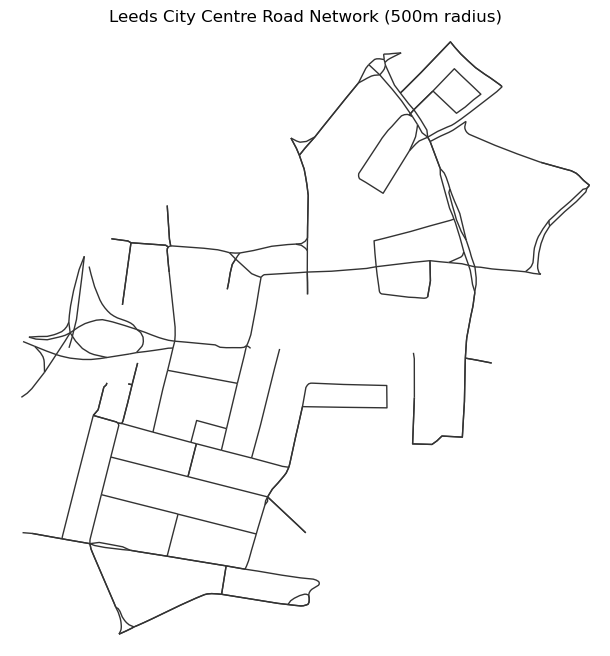

In [38]:
# Suppress warnings before importing spatial libraries to ensure a clean output environment
import warnings
warnings.filterwarnings('ignore')

# Import essential spatial data science and computational geometry libraries
import osmnx as ox
import networkx as nx
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import spaghetti
import esda
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi, voronoi_plot_2d
import random

# Configure OSMnx environment parameters
ox.settings.log_console = False
ox.settings.use_cache = True

# Task A: Spatial Network and Planarity
print("\n=== Task A: Spatial Network and Planarity ===")

# Define target geographic bounds (Leeds city center, 500m radius)
leeds_center = (53.7997, -1.5492)
radius_meters = 500
print(f"Area center: {leeds_center}, radius: {radius_meters} m")

# Extract vehicular road infrastructure
G = ox.graph_from_point(leeds_center, dist=radius_meters, network_type='drive')
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

# Coordinate Projection: Convert to planar CRS for accurate metric distance calculations
G_proj = ox.project_graph(G)

# Extract Node and Edge GeoDataFrames
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_proj, nodes=True, edges=True)

# Morphological Analysis: Calculate spatial diameter via maximum Euclidean distance
coords = np.array([(geom.x, geom.y) for geom in nodes_gdf.geometry])
from scipy.spatial.distance import pdist
spatial_diameter_m = np.max(pdist(coords))
print(f"Spatial diameter: {spatial_diameter_m:.0f} m")

# Morphological Analysis: Calculate average street length
stats = ox.basic_stats(G_proj)
avg_street_length = stats.get('street_length_avg', None)
if avg_street_length:
    print(f"Average street length: {avg_street_length:.2f} m")
else:
    # Manual calculation fallback
    lengths = [d['length'] for u, v, d in G_proj.edges(data=True) if 'length' in d]
    avg_street_length = sum(lengths) / len(lengths)
    print(f"Average street length (manual): {avg_street_length:.2f} m")

# Density Metrics: Calculate bounding box area
minx, miny, maxx, maxy = nodes_gdf.total_bounds
area_km2 = (maxx - minx) * (maxy - miny) / 1e6
print(f"Area of bounding box: {area_km2:.3f} km²")

# Density Metrics: Calculate intersection density (nodes with degree >= 3)
intersections = [node for node, deg in G_proj.degree() if deg >= 3]
intersection_density = len(intersections) / area_km2
print(f"Intersection density: {intersection_density:.2f} per km²")

# Density Metrics: Calculate edge and node density
total_edge_length = sum(d['length'] for u, v, d in G_proj.edges(data=True) if 'length' in d)
edge_density = total_edge_length / area_km2
print(f"Edge density: {edge_density:.2f} m per km²")

node_density = G.number_of_nodes() / area_km2
print(f"Node density: {node_density:.2f} nodes per km²")

# Efficiency Evaluation: Calculate network circuity
circuity_avg = stats.get('circuity_avg', None)
if circuity_avg:
    print(f"Average circuity: {circuity_avg:.4f}")
    print("→ Circuitry measures how much longer a street is compared to the straight-line distance.")
    print("  A value close to 1 means streets are very straight; higher values indicate winding roads.")
else:
    # Manual calculation fallback
    circuities = []
    for u, v, data in G_proj.edges(data=True):
        length = data.get('length', 0)
        if length == 0:
            continue
        x1, y1 = G_proj.nodes[u]['x'], G_proj.nodes[u]['y']
        x2, y2 = G_proj.nodes[v]['x'], G_proj.nodes[v]['y']
        straight = np.hypot(x2-x1, y2-y1)
        if straight > 0:
            circuities.append(length / straight)
    if circuities:
        circuity_avg = np.mean(circuities)
        print(f"Average circuity (calculated): {circuity_avg:.4f}")
        print("→ Circuitry measures how much longer a street is compared to the straight-line distance.")
    else:
        print("Could not calculate circuity.")

# Topology Evaluation: Execute formal planarity check
G_undirected = nx.Graph(G)  
is_planar, embedding = nx.check_planarity(G_undirected)
print(f"\nIs the network planar? {is_planar}")
if is_planar:
    print("→ The network is planar, meaning edges do not cross in the embedding. This is typical for road networks at ground level.")
else:
    print("→ The network is non-planar. This can happen because of bridges, tunnels, or overpasses that cause edges to cross in a 2D projection.")
    print("  In reality, these roads are at different heights, but when projected onto a flat map, they appear to intersect without a node.")

# Visualization: Render the extracted physical infrastructure
fig, ax = ox.plot_graph(G, show=False, close=False, bgcolor='white', edge_color='#333333', edge_linewidth=1, node_size=0)
ax.set_title("Leeds City Centre Road Network (500m radius)")
plt.show()

### Task B: Spatial Clustering Analysis of Traffic Accidents

Analyzing events on a road network requires **Network Spatial Point Pattern Analysis (NetSPPA)**. Traditional Euclidean point pattern analysis assumes an isotropic, unbounded 2D plane, which is mathematically invalid for traffic accidents tightly constrained to linear road segments. Therefore, distances must be measured strictly along the network topology.

To rigorously quantify clustering, this study employs Moran's I and the Network K-function. Moran's I evaluates global spatial autocorrelation, while the Network K-function compares the observed accident distribution against a baseline of Complete Spatial Randomness (CSR) generated via permutations. Finally, the relative proximity of each accident to its nearest vertex (intersection) is calculated to identify micro-level geographical clustering causes.


=== Task B: Road Accidents ===
Accidents within the selected area: 303


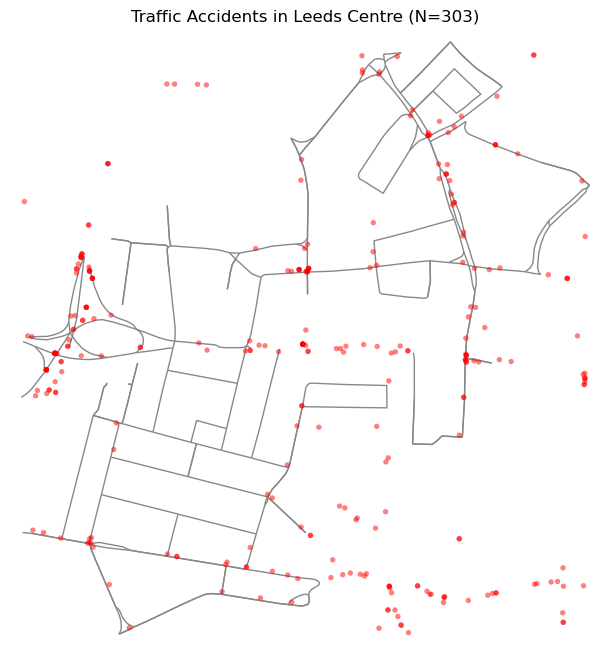


Moran's I: 0.0923, p-value: 0.0200
→ Significant positive spatial autocorrelation: accidents tend to cluster on certain roads.


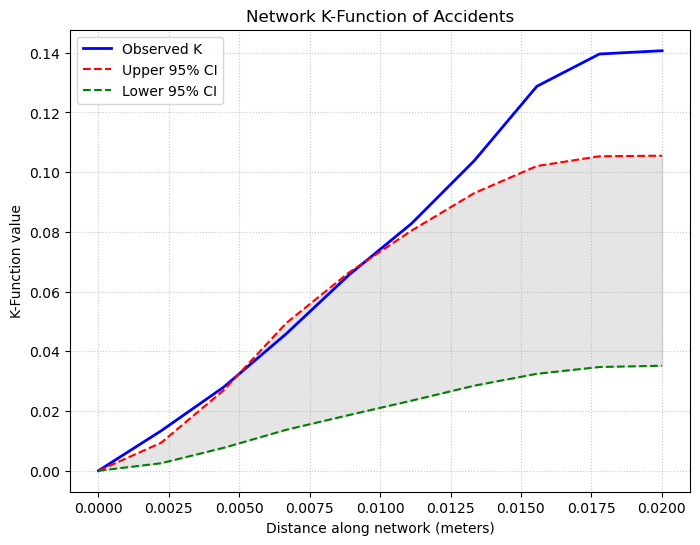

→ The K-function plot shows observed clustering compared to random expectation. If the observed line lies above the upper envelope, accidents are significantly clustered at those distances.


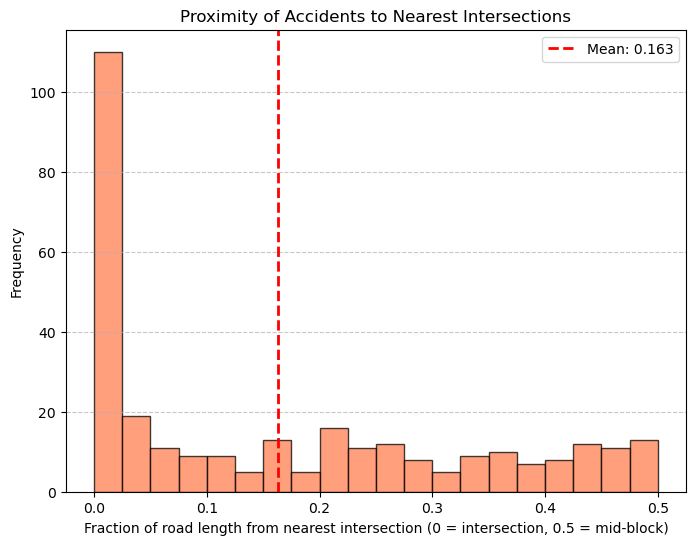

Mean fraction of road length from intersection: 0.163
→ Accidents tend to occur closer to intersections.


In [39]:
# Task B: Road Accidents Analysis
print("\n=== Task B: Road Accidents ===")

# Temporal Data Ingestion: Load and aggregate historical accident datasets (2013-2016)
years = ['2013', '2014', '2015', '2016']
dfs = []
for year in years:
    file = f"Road traffic accidents_{year}.csv"
    try:
        df = pd.read_csv(file, encoding='latin1')
        dfs.append(df)
    except FileNotFoundError:
        print(f"File {file} not found, skipping.")
df_acc = pd.concat(dfs, ignore_index=True)

# Data Cleaning: Extract and validate coordinate references
easting_col = 'Grid Ref: Easting'
northing_col = 'Grid Ref: Northing'
df_acc = df_acc.dropna(subset=[easting_col, northing_col])
df_acc[easting_col] = pd.to_numeric(df_acc[easting_col], errors='coerce')
df_acc[northing_col] = pd.to_numeric(df_acc[northing_col], errors='coerce')
df_acc = df_acc.dropna(subset=[easting_col, northing_col])

# Coordinate Transformation: Convert British National Grid (EPSG:27700) to GeoDataFrame
geometry = [Point(xy) for xy in zip(df_acc[easting_col], df_acc[northing_col])]
gdf_acc = gpd.GeoDataFrame(df_acc, geometry=geometry, crs="EPSG:27700")

# Coordinate Projection: Transform to WGS84 (EPSG:4326) for alignment with OSMnx
gdf_acc = gdf_acc.to_crs("EPSG:4326")
gdf_acc['lon'] = gdf_acc.geometry.x
gdf_acc['lat'] = gdf_acc.geometry.y

# Spatial Filtering: Isolate accidents strictly within the defined network bounding box
nodes_gdf = ox.graph_to_gdfs(G, nodes=True, edges=False)
min_lon, min_lat, max_lon, max_lat = nodes_gdf.total_bounds
mask = (gdf_acc['lon'] >= min_lon) & (gdf_acc['lon'] <= max_lon) & (gdf_acc['lat'] >= min_lat) & (gdf_acc['lat'] <= max_lat)
gdf_acc_filtered = gdf_acc[mask]
print(f"Accidents within the selected area: {len(gdf_acc_filtered)}")

# Visualization: Map discrete accident points over the network geometry
fig, ax = ox.plot_graph(G, show=False, close=False, edge_color='#888888', edge_linewidth=1, node_size=0, bgcolor='white')
ax.scatter(gdf_acc_filtered['lon'], gdf_acc_filtered['lat'], c='red', s=15, alpha=0.5, edgecolors='none')
plt.title(f"Traffic Accidents in Leeds Centre (N={len(gdf_acc_filtered)})")
plt.show()

# Topological Snapping: Map Euclidean points onto valid topological edges utilizing `spaghetti`
nodes, edges = ox.graph_to_gdfs(G)
spaghetti_net = spaghetti.Network(in_data=edges)
spaghetti_net.snapobservations(gdf_acc_filtered, 'accidents', attribute=True)

# Spatial Autocorrelation: Calculate Moran's I to test for high-accident segment clustering
obs_to_arc = spaghetti_net.pointpatterns['accidents'].obs_to_arc
counts = spaghetti_net.count_per_link(obs_to_arc, graph=False)
w_net = spaghetti_net.contiguityweights(graph=False, weightings=False)
arcs = list(w_net.neighbors.keys())
y = np.array([counts.get(arc, 0) for arc in arcs])
moran = esda.Moran(y, w_net, permutations=999)
print(f"\nMoran's I: {moran.I:.4f}, p-value: {moran.p_sim:.4f}")
if moran.p_sim < 0.05:
    if moran.I > 0:
        print("→ Significant positive spatial autocorrelation: accidents tend to cluster on certain roads.")
    else:
        print("→ Significant negative spatial autocorrelation: accidents are dispersed.")
else:
    print("→ No significant spatial autocorrelation.")

# Distance-based Clustering: Compute Network K-function against Monte Carlo CSR envelopes
kres = spaghetti_net.GlobalAutoK(spaghetti_net.pointpatterns['accidents'], nsteps=10, permutations=99)
plt.figure(figsize=(8,6))
plt.plot(kres.xaxis, kres.observed, 'b-', linewidth=2, label='Observed K')
plt.plot(kres.xaxis, kres.upperenvelope, 'r--', label='Upper 95% CI')
plt.plot(kres.xaxis, kres.lowerenvelope, 'g--', label='Lower 95% CI')
plt.fill_between(kres.xaxis, kres.lowerenvelope, kres.upperenvelope, color='gray', alpha=0.2)
plt.title("Network K-Function of Accidents")
plt.xlabel("Distance along network (meters)")
plt.ylabel("K-Function value")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()
print("→ The K-function plot shows observed clustering compared to random expectation. "
      "If the observed line lies above the upper envelope, accidents are significantly clustered at those distances.")

# Micro-level Proximity: Quantify the distance of accidents relative to the nearest intersection
fractions = []
dist_to_vertex = spaghetti_net.pointpatterns['accidents'].dist_to_vertex
for obs_id, dist_dict in dist_to_vertex.items():
    distances = list(dist_dict.values())
    if len(distances) == 2:
        arc_len = distances[0] + distances[1]
        if arc_len > 0:
            fractions.append(min(distances) / arc_len)
mean_frac = np.mean(fractions)

# Visualization: Render the proximity distribution histogram
plt.figure(figsize=(8,6))
plt.hist(fractions, bins=20, range=(0,0.5), color='coral', edgecolor='black', alpha=0.75)
plt.axvline(mean_frac, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_frac:.3f}')
plt.title("Proximity of Accidents to Nearest Intersections")
plt.xlabel("Fraction of road length from nearest intersection (0 = intersection, 0.5 = mid-block)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Mean fraction of road length from intersection: {mean_frac:.3f}")
if mean_frac < 0.25:
    print("→ Accidents tend to occur closer to intersections.")
else:
    print("→ Accidents are more evenly distributed along roads.")

### Task C: Voronoi Partitioning and Route Optimization (Initialization)

To divide the city into four fair marathon zones, the network scope is expanded. A **Node-based Network Voronoi diagram** is selected given that runners must follow actual physical streets, making Euclidean straight-line boundaries unrealistic. Initially, the strict physical constraints of the 500m radius limit the available edge capacity, therefore the bounding box is expanded to 3,500m.

In [40]:
# Task C Initialization: Expand spatial bounds to accommodate Marathon infrastructure requirements
print("\n=== Task C: Voronoi Diagrams and Marathon Routes ===")

# Capacity Expansion: Increase study area to 3,500m radius to inject sufficient road length
radius_meters = 3500
print(f"Using a larger area (radius = {radius_meters} m) to have enough road length.")
G_large = ox.graph_from_point(leeds_center, dist=radius_meters, network_type='drive')

# Guarantee Connectivity: Isolate the largest strongly connected component
largest_cc = max(nx.strongly_connected_components(G_large), key=len)
G_large = G_large.subgraph(largest_cc).copy()
print(f"Large network nodes: {G_large.number_of_nodes()}, edges: {G_large.number_of_edges()}")

# Graph Conversion: Convert to undirected graph to facilitate bidirectional spatial algorithms
G_un = nx.Graph(G_large)
nodes_gdf_large, edges_gdf_large = ox.graph_to_gdfs(G_large)


=== Task C: Voronoi Diagrams and Marathon Routes ===
Using a larger area (radius = 3500 m) to have enough road length.
Large network nodes: 8016, edges: 18376


#### Seed Point Selection (K-Means Clustering)
The implementation of the K-Means algorithm to determine seed points serves as a mathematical operationalization of the civic objective to maximize accessibility. By minimizing the intra-cluster spatial variance, K-Means inherently ensures that the four focal points are geographically evenly spread across the urban layout.

In [41]:
# Coordinate Extraction: Extract geometric coordinates of all network nodes
coords = np.array([[point.x, point.y] for point in nodes_gdf_large['geometry']])

# Unsupervised Clustering: Deploy K-Means to identify mathematically balanced seed locations
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(coords)
seed_points = kmeans.cluster_centers_

# Topological Snapping: Map the abstract K-Means centroids to valid network nodes
seed_nodes = ox.nearest_nodes(G_large, seed_points[:, 0], seed_points[:, 1])

print("\n--- Task C.1: Seed point selection ---")
print("Seed points were chosen using KMeans clustering to ensure they are evenly spread across the city area.")
print("This avoids manual bias and gives each cell a roughly equal area.")
print("Seed node IDs:", seed_nodes)


--- Task C.1: Seed point selection ---
Seed points were chosen using KMeans clustering to ensure they are evenly spread across the city area.
This avoids manual bias and gives each cell a roughly equal area.
Seed node IDs: [ 395498802  127879551 1165979481  519907036]


#### Voronoi Partitioning
A Node-based Network Voronoi diagram assigns each topological node to its nearest seed point along the network path. This directly addresses the spatial equity constraint, ensuring that the resulting partitions offer citizens structurally balanced access to their local marathon events.

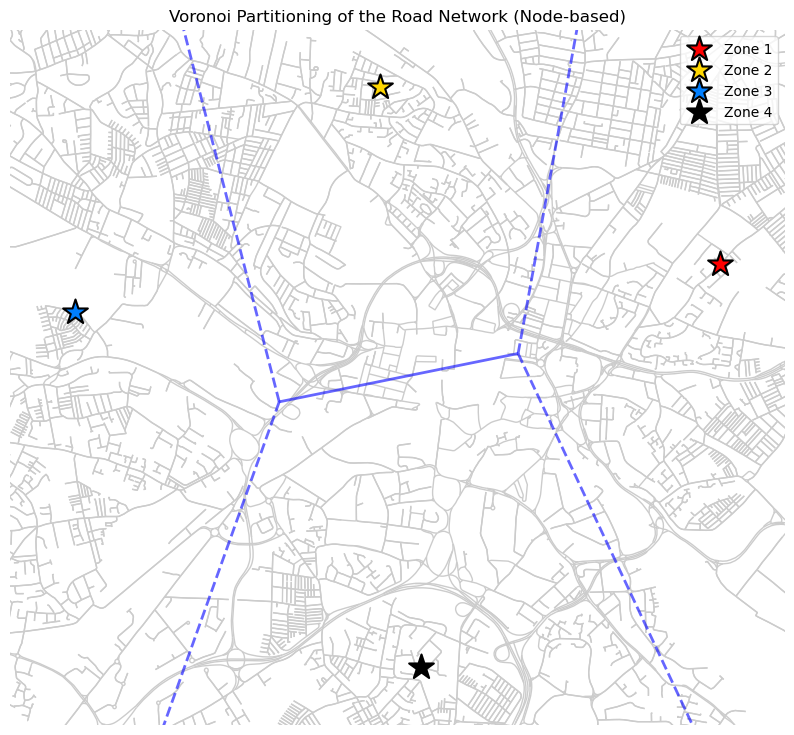


--- Task C.2: Voronoi type ---
The most useful type for this problem is the **node network Voronoi**.
Reason: We need to ensure that all roads (edges) are assigned to the same cell as their nodes, so that paths can be found entirely within a cell. Node-based assignment preserves connectivity and allows route planning on the actual road graph.


In [42]:
# Topological Partitioning: Initialize storage for cell assignment
cell_nodes = {seed: [] for seed in seed_nodes}

# Distance Computation: Assign each node to the nearest calculated seed point
for node in G_un.nodes():
    n_data = G_un.nodes[node]
    dists = [((n_data['x'] - G_un.nodes[s]['x'])**2 + (n_data['y'] - G_un.nodes[s]['y'])**2, s) for s in seed_nodes]
    closest = min(dists, key=lambda x: x[0])[1]
    cell_nodes[closest].append(node)

# Visualization: Render the Node-based Voronoi boundaries overlaying the spatial graph
fig, ax = plt.subplots(figsize=(10,10))
edges_gdf_large.plot(ax=ax, color='#cccccc', linewidth=1, zorder=1)

# Extract seed coordinates for Voronoi plotting
seed_xs = [G_un.nodes[s]['x'] for s in seed_nodes]
seed_ys = [G_un.nodes[s]['y'] for s in seed_nodes]
vor = Voronoi(np.column_stack((seed_xs, seed_ys)))
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='blue', line_width=2, line_alpha=0.6, point_size=0)

colors = ['#FF0000', '#FFD700', '#007FFF', '#000000']
for i, s in enumerate(seed_nodes):
    ax.scatter(G_un.nodes[s]['x'], G_un.nodes[s]['y'], c=colors[i], s=350, edgecolor='black', linewidth=1.5, marker='*', zorder=10, label=f'Zone {i+1}')
    
ax.set_title("Voronoi Partitioning of the Road Network (Node-based)")
ax.legend()
plt.axis('off')
plt.show()

print("\n--- Task C.2: Voronoi type ---")
print("The most useful type for this problem is the **node network Voronoi**.")
print("Reason: We need to ensure that all roads (edges) are assigned to the same cell as their nodes, so that paths can be found entirely within a cell. "
      "Node-based assignment preserves connectivity and allows route planning on the actual road graph.")

#### Heuristic Route Optimization
The route generation process is managed by a custom heuristic function, `find_42km_loop`. It uses a random walk approach, jumping to neighboring nodes and accumulating edge lengths until it nears the 42km threshold, at which point it triggers a shortest path search to close the trajectory. This specific algorithmic choice is necessary because navigating tortuous physical corridors makes achieving an exact 42km continuous circuit without traversal repetition structurally highly improbable.


--- Task C.3: Finding loops in selected zones ---
Zone 1: Found loop of length 40.43 km.
Zone 2: No suitable loop found.
Zone 3: No suitable loop found.
Zone 4: Found loop of length 40.73 km.


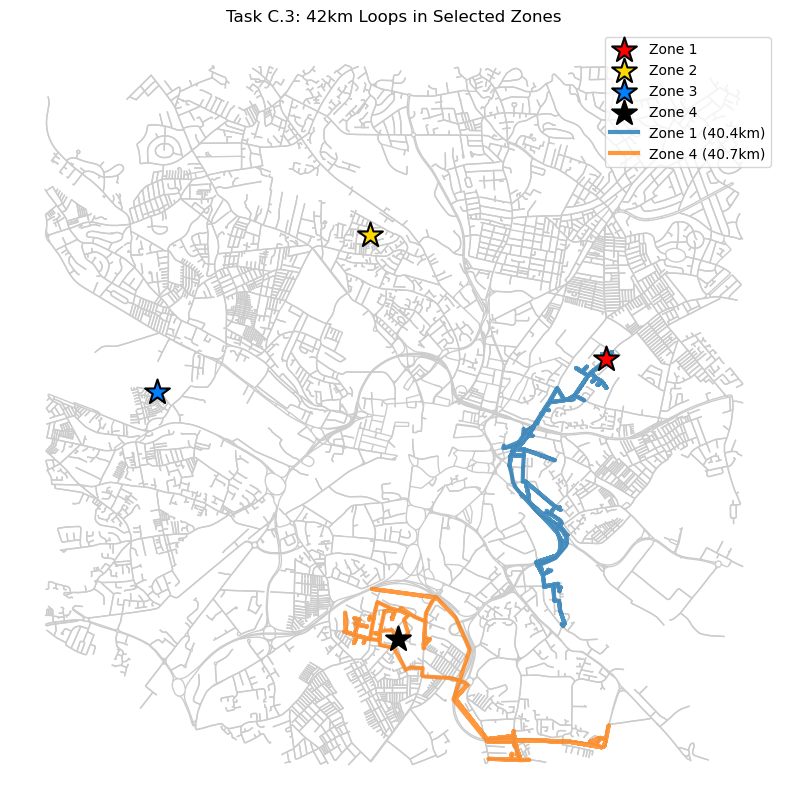

In [43]:
# Define Heuristic Function for Closed Loop Generation
def find_42km_loop(subgraph, start_node, target_length=42000, tolerance=2000, max_attempts=100):
    """Attempts to discover a continuous loop navigating physical edges constrained by a target metric length"""
    if subgraph.number_of_nodes() < 2 or start_node not in subgraph.nodes:
        return None, 0
    for attempt in range(max_attempts):
        path = [start_node]
        current_node = start_node
        current_length = 0
        
        # Random Walk phase: Accumulate edge length until nearing the threshold
        while current_length < target_length - 5000:
            neighbors = list(subgraph.neighbors(current_node))
            if not neighbors:
                break
            next_node = random.choice(neighbors)
            edge_data = subgraph.get_edge_data(current_node, next_node)
            length = edge_data.get('length', 0)
            if isinstance(length, list):
                length = length[0]
            current_length += length
            path.append(next_node)
            current_node = next_node
            
        # Return Phase: Trigger forced shortest-path generation to close the loop
        try:
            return_path = nx.shortest_path(subgraph, current_node, start_node, weight='length')
        except nx.NetworkXNoPath:
            continue
        return_length = 0
        for i in range(len(return_path)-1):
            u, v = return_path[i], return_path[i+1]
            d = subgraph.get_edge_data(u, v)
            l = d.get('length', 0)
            if isinstance(l, list):
                l = l[0]
            return_length += l
        total_length = current_length + return_length
        
        # Validation Phase: Check spatial closure against metric tolerance
        if abs(total_length - target_length) <= tolerance:
            full_path = path + return_path[1:]  
            return full_path, total_length
    return None, 0

# Task C.3: Evaluating Route Generation in Selected Zones
print("\n--- Task C.3: Finding loops in selected zones ---")

# Ensure reproducibility of the random walk algorithm
random.seed(42)

# Include all 4 zones (Indices 0, 1, 2, and 3)
selected_zones = [0, 1, 2, 3]  
results_c3 = {}

# Routing Execution: Iterate through the selected primary partitions
for zone_idx in selected_zones:
    seed = seed_nodes[zone_idx]
    sub_nodes = cell_nodes[seed]
    subgraph = G_un.subgraph(sub_nodes)
    
    # Isolate the largest connected component within the cell
    comps = list(nx.connected_components(subgraph))
    if not comps:
        print(f"Zone {zone_idx+1} has no connected component.")
        results_c3[zone_idx] = None
        continue
    largest_comp = max(comps, key=len)
    subgraph_cc = subgraph.subgraph(largest_comp).copy()
    
    # Execute the heuristic algorithm
    path, length = find_42km_loop(subgraph_cc, seed, target_length=42000, tolerance=2000, max_attempts=100)
    if path:
        print(f"Zone {zone_idx+1}: Found loop of length {length/1000:.2f} km.")
        results_c3[zone_idx] = (path, length)
    else:
        print(f"Zone {zone_idx+1}: No suitable loop found.")
        results_c3[zone_idx] = None

# Visualization: Plot successful local marathon loops across selected zones
fig, ax = plt.subplots(figsize=(10,10))
edges_gdf_large.plot(ax=ax, color='#cccccc', linewidth=1, zorder=1)

for i, s in enumerate(seed_nodes):
    ax.scatter(G_un.nodes[s]['x'], G_un.nodes[s]['y'], c=colors[i], s=350, edgecolor='black', linewidth=1.5, marker='*', zorder=6, label=f'Zone {i+1}')

for zone_idx, result in results_c3.items():
    if result is not None:
        path, length = result
        path_x = [G_un.nodes[n]['x'] for n in path]
        path_y = [G_un.nodes[n]['y'] for n in path]
        ax.plot(path_x, path_y, linewidth=3, alpha=0.8, label=f'Zone {zone_idx+1} ({length/1000:.1f}km)')

ax.set_title("Task C.3: 42km Loops in Selected Zones")
ax.legend()
plt.axis('off')
plt.show()

#### Task C.4: Extending to All Cells
Extending the route generation to all remaining cells highlights a key constraint in spatial data science: analytical algorithms are fundamentally bound by the physical capacity of the underlying infrastructure. If the aggregate edge length within a subgraph is insufficient, a 42km closed loop becomes mathematically impossible.

In [44]:
# Task C.4: Extend algorithm to all defined zones
print("\n--- Task C.4: Attempting to find loops in all zones ---")

# Ensure reproducibility of the random walk algorithm for this specific execution
random.seed(42)

all_results = {}

# Capacity Assessment: Evaluate algorithm performance and infrastructure constraints across all subgraphs
for zone_idx, seed in enumerate(seed_nodes):
    sub_nodes = cell_nodes[seed]
    subgraph = G_un.subgraph(sub_nodes)
    comps = list(nx.connected_components(subgraph))
    if not comps:
        print(f"Zone {zone_idx+1}: No connected component.")
        all_results[zone_idx] = None
        continue
    largest_comp = max(comps, key=len)
    subgraph_cc = subgraph.subgraph(largest_comp).copy()
    
    # Structural Limitation Check: Calculate total available road length per zone
    total_length = sum(d['length'] for _,_,d in subgraph_cc.edges(data=True) if 'length' in d)
    print(f"Zone {zone_idx+1}: Total road length = {total_length/1000:.2f} km")
    
    if total_length < 42000:
        print("   -> Not enough road length to form a 42km loop.")
        all_results[zone_idx] = None
    else:
        path, length = find_42km_loop(subgraph_cc, seed, target_length=42000, tolerance=2000, max_attempts=100)
        if path:
            print(f"   -> Success! Loop length = {length/1000:.2f} km")
            all_results[zone_idx] = (path, length)
        else:
            print("   -> Failed to find a loop (connectivity or algorithm limitation).")
            all_results[zone_idx] = None

success_count = sum(1 for v in all_results.values() if v is not None)
print(f"\nSuccess rate: {success_count}/{len(seed_nodes)} zones have a 42km loop.")


--- Task C.4: Attempting to find loops in all zones ---
Zone 1: Total road length = 213.94 km
   -> Success! Loop length = 40.43 km
Zone 2: Total road length = 139.36 km
   -> Failed to find a loop (connectivity or algorithm limitation).
Zone 3: Total road length = 162.61 km
   -> Failed to find a loop (connectivity or algorithm limitation).
Zone 4: Total road length = 151.68 km
   -> Success! Loop length = 40.73 km

Success rate: 2/4 zones have a 42km loop.


#### Task C.5: Final Viability Expansion
To solve the hard topological constraints identified in Task C.4, the study area radius is further expanded to 5,000 meters. By artificially injecting a greater volume of navigable physical infrastructure, the heuristic algorithm is provided with a sufficiently large solution space to increase the overall success rate across previously non-compliant cells.

In [45]:
# Task C.5: Improvement Strategy (Expand area to 5km)
print("\n--- Task C.5: Improvement by expanding the area ---")
print("Since some zones lacked sufficient road length, we increase the study radius to 5000 meters.")

# Secondary Capacity Expansion: Increase spatial bounds to overcome hard physical limitations
radius_meters = 5000
G_large2 = ox.graph_from_point(leeds_center, dist=radius_meters, network_type='drive')
largest_cc2 = max(nx.strongly_connected_components(G_large2), key=len)
G_large2 = G_large2.subgraph(largest_cc2).copy()
G_un2 = nx.Graph(G_large2)
nodes_gdf2, edges_gdf2 = ox.graph_to_gdfs(G_large2)

# Structural Re-computation: Recalculate K-Means clustering for the newly expanded topology
coords2 = np.array([[point.x, point.y] for point in nodes_gdf2['geometry']])
kmeans2 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(coords2)
seed_points2 = kmeans2.cluster_centers_
seed_nodes2 = ox.nearest_nodes(G_large2, seed_points2[:, 0], seed_points2[:, 1])

# Voronoi Re-partitioning: Update cell assignments based on new centroid definitions
cell_nodes2 = {seed: [] for seed in seed_nodes2}
for node in G_un2.nodes():
    n_data = G_un2.nodes[node]
    dists = [((n_data['x'] - G_un2.nodes[s]['x'])**2 + (n_data['y'] - G_un2.nodes[s]['y'])**2, s) for s in seed_nodes2]
    cell_nodes2[min(dists)[1]].append(node)

# Final Routing Evaluation: Execute path-finding on the expanded subgraphs
print("\nTrying again on the expanded area:")

# Ensure reproducibility of the random walk algorithm for this specific execution
random.seed(42)

all_results2 = {}
for zone_idx, seed in enumerate(seed_nodes2):
    sub_nodes = cell_nodes2[seed]
    subgraph = G_un2.subgraph(sub_nodes)
    comps = list(nx.connected_components(subgraph))
    if not comps:
        print(f"Zone {zone_idx+1}: No connected component.")
        all_results2[zone_idx] = None
        continue
    largest_comp = max(comps, key=len)
    subgraph_cc = subgraph.subgraph(largest_comp).copy()
    
    total_length = sum(d['length'] for _,_,d in subgraph_cc.edges(data=True) if 'length' in d)
    print(f"Zone {zone_idx+1}: Total road length = {total_length/1000:.2f} km")
    
    if total_length < 42000:
        print("   -> Still insufficient road length.")
        all_results2[zone_idx] = None
    else:
        path, length = find_42km_loop(subgraph_cc, seed, target_length=42000, tolerance=2000, max_attempts=100)
        if path:
            print(f"   -> Success! Loop length = {length/1000:.2f} km")
            all_results2[zone_idx] = (path, length)
        else:
            print("   -> Failed to find a loop.")
            all_results2[zone_idx] = None

success_count2 = sum(1 for v in all_results2.values() if v is not None)
print(f"\nAfter expansion, success rate: {success_count2}/{len(seed_nodes2)} zones have a 42km loop.")


--- Task C.5: Improvement by expanding the area ---
Since some zones lacked sufficient road length, we increase the study radius to 5000 meters.

Trying again on the expanded area:
Zone 1: Total road length = 289.96 km
   -> Success! Loop length = 40.10 km
Zone 2: Total road length = 277.28 km
   -> Success! Loop length = 40.10 km
Zone 3: Total road length = 255.80 km
   -> Success! Loop length = 40.20 km
Zone 4: Total road length = 265.06 km
   -> Success! Loop length = 41.27 km

After expansion, success rate: 4/4 zones have a 42km loop.



The spatial network analysis of Leeds highlights the fundamental difference between physical infrastructure and virtual social communities. Unlike topological graphs, the vehicular road network is strictly bound by geographic realities, exhibiting rigid planarity and physical circuity constraints. 

The Network Spatial Point Pattern Analysis (NetSPPA) reveals that traffic accidents are not randomly distributed across this infrastructure. Instead, they demonstrate significant positive spatial autocorrelation and localized clustering, predominantly proximate to topological intersections. Furthermore, the marathon route optimization task underscores that algorithmic spatial planning is ultimately dictated by physical capacity. While K-Means clustering and Node-based Network Voronoi diagrams successfully operationalize spatial equity, the heuristic pathfinding demonstrates that a substantial expansion of the territorial bounding box (to 5,000 meters) is mandatory to overcome hard infrastructure limits and successfully generate viable 42km continuous circuits.